In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import ase
import os
import ase.io
import time

In [2]:
def get_size(df):
    return len(df.structure)


In [3]:
par_el = 'run_full'
root = '/blue/hennig/jasongibson/diff_model'
root = f'{root}/materials/{par_el}/mp_relaxed/'
df = pd.read_pickle(f'pkl_files/df_cpd_{par_el}_strict.pkl')
df = df.loc[df.tcad_cpd >= 5]
df.shape

(1363, 137)

In [4]:
def check_second_to_last_line(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        second_to_last_line = lines[-2].strip()
        
    return second_to_last_line == 'JOB DONE.'

In [5]:
def check_max_iter(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    iters = []
    for line in lines:    
        if ('iter' in line) and ('total cpu time' in line):
            it = line.split('#')[-1].split()[0]
            iters.append(int(it))
    if len(iters) == 0:
        iters = [0]
    return max(iters)

In [6]:
def check_last_line(file_path):
    try:
        with open(file_path, 'r') as file:
            lines = file.readlines()
            last_line = lines[-1].strip()
        
        return last_line == 'stopping ...'
    except:
        return False

def check_converge(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if "No convergence has been achieved" in line:
            return False
    return True

def check_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    try:
        if 'reading input file' in lines[-4]:
            return True
        else:
            return False
    except:
        return False

def get_mod_time(file_path):
    modification_time = os.path.getmtime(file_path)
    current_time = time.time()
    return current_time - modification_time

In [7]:
import glob


In [8]:
inds = []
complete = []
fail = []
running = []
long = []
max_iter = []

for index, row in df.iterrows():
    jobdir = f'{root}{row.name}/'
    filename = jobdir+"/ph_elph.out"
    if os.path.isfile(jobdir+'a2F.dos20'):
        complete.append(index)
    elif os.path.isfile(filename):
        fc_files = glob.glob(f'{jobdir}*.fc')
        dyn_files = glob.glob(f'{jobdir}*.dyn15')
        if len(fc_files)>=1:
            fail.append(index)
        elif len(dyn_files)>=1:
            # long.append(index)
            inds.append(index)
        elif get_mod_time(filename) < 3600:
            running.append(index)     
        # elif get_mod_time(filename) < 36*3600:
        #     inds.append(index)             
        elif check_file(filename) == True:
            inds.append(index) 
        elif not check_converge(filename):
            fail.append(index)            
        # elif check_max_iter(filename) == 150:
        #     max_iter.append(index)
        elif not check_last_line(filename):
            inds.append(index)
        elif os.path.isfile(jobdir+'CRASH'):
            print(index)            
            fail.append(index)              
        else:
            fail.append(index)
          

    else:
        inds.append(index)

In [9]:
def get_size(df):
    return len(df.structure)

In [10]:
df['natoms'] = df.apply(get_size, axis = 1)

In [11]:

df.shape

(1363, 137)

In [12]:
net =  inds #+ fail

In [13]:
len(fail)

387

In [14]:
len(complete)

682

In [15]:
with open(root+'list_done', "w") as file:
    for item in complete:
        # Write each item to the file followed by a newline
        file.write(f"{item}\n")

In [16]:
len(inds)

294

In [17]:
d = df.loc[complete]

In [18]:
# d.loc[d.sgn==194]

In [19]:
df = df.loc[inds]

In [20]:
df.shape

(294, 137)

In [21]:
def get_nelements(df):
    return len(set(df.structure.get_chemical_symbols()))
df['nelements'] = df.apply(get_nelements,axis=1)

/scratch/local/65299106/ipykernel_568719/900407074.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['nelements'] = df.apply(get_nelements,axis=1)


In [26]:
# d = df.loc[df.nelements>2]
# d[['parent_formula','mp_id','sgn','eah','formula','tcad_cpd','mp_eah']].loc[d.index.isin(fail)]

In [27]:
# df.loc[inds][['formula','tcad_cpd','sgn']]

In [25]:
# df_a2f = pd.read_pickle(f'pickle_files/all_tc.pkl')

In [29]:
df.shape

(302, 138)

In [30]:
df_filtered = df.merge(df_a2f[['sgn', 'formula']], on=['sgn', 'formula'], how='left', indicator=True)
df_filtered = df_filtered[df_filtered['_merge'] == 'left_only']#.drop('_merge', axis=1)

NameError: name 'df_a2f' is not defined

In [31]:
df_filtered.columns

Index(['al_id', 'band_gap', 'eah', 'structure', 'elements', 'natoms',
       'formula', 'pred_avg', 'lamb', 'w2', 'wlog', 'tc', 'tcad', 'sgn',
       'freq', 'phdos', 'site_phdos', 'dyn_stable', 'tcad_cpd', 'nelements',
       '_merge'],
      dtype='object')

In [32]:
try:
    df = df.loc[df.al_id.isin(df_filtered.al_id)]
except:
    df = df.loc[df.mp_id.isin(df_filtered.mp_id)]

In [33]:
# d = df.loc[complete]
# print(df.shape)

In [34]:
# df = df.loc[net]
# print(df.shape)

In [31]:
len(inds)

302

In [32]:
df.sort_values(by=['sgn','natoms','tcad_cpd'],ascending=[False,True,False],inplace=True)

In [33]:
df.shape

(302, 138)

In [26]:
d = df.loc[df.natoms<=12]
d = d.loc[d.eah<=.1]

In [27]:
d.shape

(253, 138)

In [28]:
df[['formula','tcad_cpd','sgn','natoms','eah']].head(30)

,formula,tcad_cpd,sgn,natoms,eah
3853,HfNb3,17.132709,123,4,0.016015
4826,Mo6Rh2,16.985788,2,8,0.051618
21606,HfTc4Zr,16.710446,8,6,0.034444
254,HfTc4Zr,16.689593,1,6,0.034327
6854,HfNbTc4,16.623532,146,6,0.035316
43138,Mo3Tc3,16.615119,2,6,-0.043637
142485,HfTc4Zr,16.593178,82,6,0.034308
25154,HfTc4Y,16.525115,44,6,0.027250
5573,HfTc4Zr,16.463375,146,6,0.034246
8791,Mo4Tc2,16.456744,63,6,-0.012071


In [29]:
len(df)

294

In [34]:
df.sort_values('sgn',ascending=False)#[['formula','tcad_cpd','sgn','natoms','eah']]

,dirs,Structure,final_E,PBE,GLLB-SC,HSE,SCAN,E_form,is_metal,formula,...,pred_96,pred_97,pred_98,pred_99,lamb_cpd,w2_cpd,wlog_cpd,tc_cpd,tcad_cpd,nelements
50411,tc10_w2,"[[1.93631061 3.38417319 2.48124714] Mn, [1.936...",-116.032532,-0.007586,0.337319,-0.007491,0.256649,-0.152603,True,Mn6Nb4Ru2,...,"[0.005651207779406031, 0.0, 0.0228632114791185...","[0.0, 0.0, 0.011628473763639319, 0.03815966183...","[0.0, 0.0, 0.0, 0.04966032654571637, 0.1058585...","[0.0, 0.0, 0.0012843783400469904, 0.0394010449...",0.741529,231.089316,194.836960,7.757481,8.076357,3
52163,tc10_w2,"[[-0.18178358 1.94076695 7.59876084] Re, [-0...",-44.894569,-0.008349,0.683176,-0.008055,0.228368,-0.155820,True,IrMoRe2,...,"[0.0, 0.008462586950360609, 0.0127607021640806...","[0.0, 0.0, 0.0, 2.2715219400473892e-05, 0.0368...","[0.0, 0.0, 0.0054720397498529035, 0.0857266142...","[0.0, 0.0, 0.0, 0.011206304491116136, 0.088630...",0.760043,206.021650,183.285010,7.708232,8.020172,3
147296,tc15_w2,"[[2.5683548 1.24267628 1.4217861 ] La, [0.506...",-22.277792,-0.007356,0.230671,-0.008008,0.120189,-1.055560,True,IrLaSi,...,"[0.044209829286113285, 0.006691228110444911, 0...","[0.015321147556203835, 0.0, 0.0840329904971316...","[0.0, 0.044275516320612225, 0.1494558916229308...","[0.003822703068300758, 0.0, 0.1137984326680821...",0.845441,170.738294,103.545192,5.410205,5.731525,3
189636,tc15_w2,"[[0.3483648 0.46119209 8.23974002] Hf, [1.926...",-33.313854,-0.009029,0.002216,-0.008188,-0.008703,-0.009398,True,HfScZr2,...,"[0.0, 0.0, 0.02879134885335233, 0.065701827099...","[0.0, 0.0, 0.02599186408221048, 0.079434596896...","[0.0, 0.0, 0.08007523893927872, 0.078788315654...","[0.0, 0.0, 0.02068040441202096, 0.033177066592...",0.805296,173.457669,146.892846,6.976622,7.301250,3
25068,tc10_w2,"[[2.00396047 3.40666342 7.06404678] Zr, [-0.66...",-137.836761,-0.008280,0.034481,-0.008408,-0.006220,-0.377272,True,Re8Zr4,...,"[0.0, 0.0, 0.0, 0.10681792640780612, 0.2905384...","[0.0, 0.0, 0.004017364355760848, 0.07977519698...","[0.0, 0.0, 0.0, 0.06377793736773164, 0.3352110...","[0.0, 0.0, 0.0, 0.041252875411867444, 0.252674...",1.086118,172.980551,154.264045,12.121598,12.962400,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105412,tc15_w2,"[[2.47027629 0.91638084 4.60887109] Tc, [1.944...",-63.971931,-0.007079,0.513875,-0.007213,0.522701,-0.009445,True,Mo4Tc2,...,"[0.0, 0.0, 0.0, 0.0, 0.0036711170561700194, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.11707544271713834,...","[0.0, 0.0, 0.0, 0.022264887083578863, 0.024047...","[0.0, 0.0, 0.0, 0.0, 0.026822365221429775, 0.1...",1.051964,217.126245,200.542425,15.060789,16.008486,2
187177,tc15_w2,"[[0.7943061 3.10854409 2.12511865] Nb, [2.239...",-60.812450,-0.007156,0.474532,-0.007086,0.484193,-0.396815,True,Ir2MoNb3,...,"[0.0, 0.01038480414435518, 0.01762611247645462...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.07067621427710566,...","[0.035234240808902605, 0.0, 0.0541138995411769...","[0.012704409673424759, 0.0, 0.0, 0.01711623871...",0.704362,207.048821,172.995449,6.108031,6.341607,3
59881,tc10_w2,"[[1.50496939 1.83082395 2.74399231] Tc, [0.084...",-63.514297,-0.006549,0.583847,-0.006821,0.041180,-0.008527,True,Mo3OsRuTc,...,"[0.0, 0.0, 0.0030293875985727757, 0.0308731024...","[0.0, 0.0, 0.0, 0.0, 0.026675581240987612, 0.1...","[0.0, 0.0, 0.0, 0.03041878808123055, 0.0686877...","[0.0, 0.0, 0.0, 0.0005052040497090469, 0.04427...",0.794696,220.090422,198.644900,9.182779,9.573886,4
87482,tc10_w2,"[[5.3459665 2.79134671 6.31984956] Hf, [0.647...",-61.399109,-0.006782,0.406920,-0.008251,0.082139,-0.050922,True,HfNb4Tc,...,"[0.0, 0.0, 0.0025846883454066273, 0.0127225546...","[0.0, 0.0, 0.012135829532024056, 0.03379338371...","[0.0, 0.0, 0.0, 0.06373318286448922, 0.0727334...","[0.0, 0.0, 0.016248604977061976, 0.04292813861...",0.657319,221.634735,196.614472,5.825507,6.014803,3


In [35]:
with open(root+'list_ele_ph', "w") as file:
    for item, _ in df.iterrows():
        # Write each item to the file followed by a newline
        file.write(f"{item}\n")

In [97]:
df

,al_id,band_gap,eah,structure,elements,natoms,formula,pred_avg,lamb,w2,...,pred_96,pred_97,pred_98,pred_99,lamb_cpd,w2_cpd,wlog_cpd,tc_cpd,tcad_cpd,nelements
515455,agm003176848,0.0475,0.088231,"(Atom('Cr', [0.00011390892637447444, -8.468219...","[Cr, Cr, Ir, Os]",4,Cr2IrOs,"[0.0015635463698207377, 7.178222941476812e-05,...",0.692443,257.822099,...,"[0.0, 0.0, 0.0, 0.03012988888543449, 0.1074052...","[0.0, 0.0, 0.0, 0.003148553392486989, 0.056146...","[0.0, 0.0, 0.0010047619670424477, 0.1062504968...","[0.0, 0.0, 0.0, 0.0, 0.015370814994606602, 0.0...",0.746338,257.721467,224.267390,9.059906,9.424951,3
1448630,agm003181280,0.0866,0.085155,"(Atom('Re', [2.3416442811257245, -0.0010517530...","[Re, Ir, Ir, Ru]",4,Ir2ReRu,"[0.00084821767765281, 0.00014088891536146922, ...",0.615461,219.118729,...,"[0.0, 0.0, 0.0, 0.0190845618786655, 0.06562458...","[0.0, 0.0, 0.003996885454679123, 0.0, 0.0, 0.0...","[0.005482420117683683, 0.0, 0.0243038758714467...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0532603088530725, ...",0.616526,219.831315,200.693582,4.975590,5.117675,3
1101807,agm001618403,0.0220,0.134886,"(Atom('Cr', [0.0, 0.0, 1.8236324323203776], in...","[Cr, Mn, Mn, Rh, H]",5,HCrMn2Rh,"[0.0009056348663337256, 0.00021760063188399823...",0.573637,285.653482,...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.006999863676709775...","[0.0, 0.0, 0.02960640770224811, 0.039958318367...","[0.0, 0.0, 0.0, 0.007558824765861782, 0.0, 0.0...","[0.011163224105243341, 0.0, 0.0, 0.0, 0.0, 0.0...",0.568569,287.041725,262.962815,5.078364,5.206053,4
651076,agm003183246,0.0617,0.086561,"(Atom('P', [1.4446533829678578, 1.798427955353...","[P, Mo, Tc, Tc]",4,MoPTc2,"[0.0005099350471624671, 0.00019484883823433718...",0.754244,248.900539,...,"[0.0, 0.0, 0.0, 0.0, 0.01422900549415351, 0.02...","[0.0, 0.0, 0.0, 0.003639702555824624, 0.008558...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0456348715738...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.05723748919200998,...",0.596597,273.000493,242.516641,5.451950,5.604379,3
1309571,agm001850166,0.0396,0.141735,"(Atom('Sn', [0.0015524590306066344, 0.00155508...","[Sn, Sn, Ti]",3,Sn2Ti,"[0.01269404170478967, 0.0026873895697965182, 0...",0.745010,170.975627,...,"[0.011277232102480056, 0.0, 0.0050565455436107...","[0.0, 0.0, 0.0239851669319573, 0.0458513226048...","[0.05102802308877596, 0.0, 0.00939203296835744...","[0.0, 0.0, 0.07006191608718965, 0.155693817522...",0.715506,182.903384,145.987991,5.351791,5.568991,2
2029031,agm003624225,0.0396,0.034694,"(Atom('Cr', [2.5299342784949945, 4.20030244665...","[Cr, Cr, Mo, Mo, H, H, H, H]",8,H4Cr2Mo2,"[0.0011560748335702324, 0.00020258065713327735...",0.621274,293.780099,...,"[0.0, 0.0, 0.018913163050916393, 0.02625748920...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1283723304646...","[0.0, 0.0, 0.0, 0.05579676862641691, 0.0218076...","[0.0, 0.0, 0.0, 0.0, 0.010152835916823259, 0.0...",0.621508,265.299429,235.906735,5.986371,6.164424,3
2308184,agm003732134,0.0849,0.122971,"(Atom('Tc', [2.9690207393970587, 4.82193020484...","[Tc, Tc, Tc, Os, Ru]",5,OsRuTc3,"[0.0012175475870322117, 5.27865564725969e-05, ...",0.727571,238.452373,...,"[0.0032975575028878837, 0.0, 0.0, 0.0, 0.05845...","[0.0, 0.0, 0.0, 0.0, 0.04090368401120058, 0.16...","[0.0007238271836209093, 0.0, 0.0, 0.0, 0.04099...","[0.0, 0.0, 0.016098949402328856, 0.02274244716...",0.942039,210.994517,193.626910,12.258620,12.919054,3


In [53]:
df.sort_values(by = ['natoms', 'tcad_cpd'], ascending=[True, False],inplace = True)

In [54]:
df.shape

(59, 29)

In [56]:
df

,final_E,PBE,GLLB-SC,HSE,SCAN,E_form,is_metal,structure,formula,pred_avg,...,eah,natoms,mp_eah,tcad_mp,freq,phdos,site_phdos,dyn_stable,tcad_cpd,nelements
id,,,,,,,,,,,,,,,,,,,,,
550591,-23.431351,-0.007004,0.501482,-0.006968,0.396730,-0.083143,True,"(Atom('Tc', [1.548477003679065, 1.548477003679...",TcW,"[0.00014343910103779335, 0.0004543440450610737...",...,-0.056302,2,0.080906,5.559827,"[-1.3999935528566827e-07, 0.1000007265648134, ...","[0.0, 3.5729384325389368e-06, 1.42917750783499...","[[0.0, 1.2362859875892453e-06, 4.9239315798757...",True,13.522565,2
587237,-23.431353,-0.007004,0.501469,-0.006968,0.396752,-0.083141,True,"(Atom('Tc', [1.5484853808302659, 1.54848538083...",TcW,"[0.00013977459168731043, 0.0004480257337489901...",...,-0.056303,2,0.080905,5.559810,"[0.0, 0.10000086656411722, 0.20000173312823444...","[0.0, 3.5654753993277905e-06, 1.42619230876201...","[[0.0, 1.2337050147550296e-06, 4.9137689993410...",True,13.520457,2
13699,-33.497372,-0.009183,0.048757,-0.009764,-0.005740,-0.568619,True,"(Atom('La', [-1.5577452463469452, -0.550334327...",La4Pd2,"[0.03688569194124514, 0.06472251301458896, 0.3...",...,0.007092,6,0.090817,6.266916,"[-0.008319588874575025, 0.09168127768966619, 0...","[0.0, 0.00026603135086127787, 0.00108354861713...","[[0.0, 4.796899323191726e-05, 0.00019487151452...",True,7.887547,2
98553,-31.997761,-0.009410,-0.007903,-0.009547,-0.011323,-0.946149,True,"(Atom('La', [3.697491578565715, 0.995779185543...",La2Sb4,"[0.016143806796846114, 0.010826306319683706, 0...",...,0.069139,6,0.051222,5.152519,"[-0.012542349481736772, 0.08745851708238046, 0...","[0.0, 4.064618445310219e-05, 0.000165113023785...","[[0.0, 7.362628286605183e-06, 2.98328197474889...",True,5.040387,2
441292,-98.148605,-0.007084,0.518074,-0.007193,0.441468,-0.025552,True,"(Atom('Tc', [0.0, 0.0, 0.0], index=0), Atom('T...",Tc2W6,"[0.0023943178138253886, 0.0005118801068345637,...",...,0.040174,8,0.060038,7.925362,"[0.0, 0.10000086656411722, 0.20000173312823444...","[0.0, 3.1775679945363095e-05, 0.00012710312918...","[[0.0, 2.3839316894034e-06, 9.489914489806277e...",True,7.896297,2
248061,-45.855251,-0.022080,-0.014303,-0.008673,-0.020304,-0.637958,True,"(Atom('La', [3.361589408020298, 5.815749786449...",I2La6Rh,"[0.03702045795996353, 0.015860107003460765, 0....",...,0.098983,9,0.078316,6.926870,"[-0.003951191822683224, 0.09604967474093806, 0...","[0.0, 0.0003903222452759442, 0.001572308183489...","[[0.0, 4.519525398914624e-05, 0.00018065196731...",True,5.974738,3
58,-83.624634,-0.008202,0.474171,-0.004218,0.319181,-0.159581,True,"(Atom('Zr', [1.1312402344264547, 1.52316538679...",Co2Zr8,"[0.013527439163770699, 0.0014173166447797479, ...",...,0.065931,10,0.088984,6.271300,"[-0.006517356263578258, 0.09348351029991904, 0...","[0.0, 8.96437524142785e-05, 0.0003620402249054...","[[0.0, 9.539114284458509e-06, 3.80879000469251...",True,9.612081,2
55,-86.198700,-0.007540,0.002772,-0.010018,-0.003981,-0.352371,True,"(Atom('Zr', [1.157169097149575, 1.596927635122...",Rh2Zr8,"[0.004296469384647184, 0.002124626736846199, 0...",...,0.024116,10,0.050250,5.475233,"[-0.0032735975010941935, 0.09672726906289905, ...","[0.0, 4.017010975798899e-05, 0.000162102624980...","[[0.0, 3.904769931964909e-06, 1.57068328042229...",True,7.999309,2
176589,-123.607124,0.042500,0.566790,-0.002476,0.406207,-0.166175,True,"(Atom('Nb', [-2.564795170467704e-06, 2.9595763...",Cr2Nb4Tc6,"[0.00503454054416519, 0.0005689058124253614, 0...",...,-0.058554,12,0.046443,11.170673,"[-1.3831721300875445e-06, 0.0999994833920231, ...","[0.0, 5.759448264844439e-05, 0.000230379018059...","[[0.0, 5.043866161265726e-06, 2.02170828320146...",True,17.756937,3


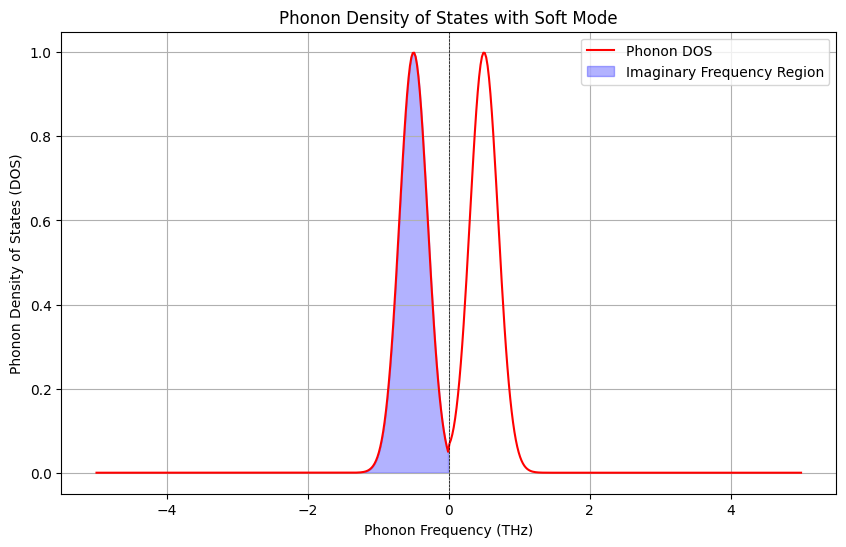

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Phonon frequency range
frequency = np.linspace(-5, 5, 500)

# Example of a soft mode that becomes imaginary (frequency squared becomes negative)
# This will create a peak near zero frequency
dos = np.exp(-0.5 * ((frequency - 0.5) / 0.2)**2) + 0.5 * np.exp(-0.5 * ((frequency + 0.5) / 0.2)**2)
dos[frequency < 0] = np.exp(-0.5 * ((frequency[frequency < 0] + 0.5) / 0.2)**2)  # Imaginary part contribution

# Plotting the phonon DOS vs phonon frequency
plt.figure(figsize=(10, 6))
plt.plot(frequency, dos, 'r-', label='Phonon DOS')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  # Line at zero frequency for reference
plt.fill_between(frequency, dos, where=(frequency < 0), color='blue', alpha=0.3, label='Imaginary Frequency Region')

# Titles and labels
plt.title('Phonon Density of States with Soft Mode')
plt.xlabel('Phonon Frequency (THz)')
plt.ylabel('Phonon Density of States (DOS)')
plt.legend()
plt.grid(True)

plt.show()


In [67]:
with open(root+'list_ele_ph', "w") as file:
    for item, _ in df.iterrows():
        # Write each item to the file followed by a newline
        file.write(f"{item}\n")

In [63]:
only_in

NameError: name 'only_in' is not defined

In [83]:
len(only_in)

22

In [32]:
root = f'/blue/hennig/jasongibson/elemental_sub/materials/{par_el}/mp_relaxed/'

def get_tot_ph(df):
    jobdir = f'{root}{df.name}/'
        
    filename = jobdir+"/relax.out"
    try:
        atom_obj = ase.io.read(filename)
    except:
        return np.nan   
    if os.path.isfile(jobdir+'phonon_2x2x2/.dos'):
        filename = jobdir+"/relax.out"
        atom_obj = ase.io.read(filename)
        freq, phdos, site_proj_phdos = get_freq_phonon_2x2x2_interpolated_DOS(jobdir +"/phonon_2x2x2/"+".dos", atom_obj.get_global_number_of_atoms())
    else:
        phdos = np.nan
    return phdos 

def get_site_ph(df):
    jobdir = f'{root}{df.name}/'
    filename = jobdir+"/relax.out"
    try:
        atom_obj = ase.io.read(filename)
    except:
        return np.nan   
    if os.path.isfile(jobdir+'phonon_2x2x2/.dos'):
        filename = jobdir+"/relax.out"
        atom_obj = ase.io.read(filename)
        freq, phdos, site_proj_phdos = get_freq_phonon_2x2x2_interpolated_DOS(jobdir +"/phonon_2x2x2/"+".dos", atom_obj.get_global_number_of_atoms())
    else:
        site_proj_phdos = np.nan
    return site_proj_phdos 

def get_freq(df):
    jobdir = f'{root}{df.name}/'
    try:
        filename = jobdir+"/relax.out"
        atom_obj = ase.io.read(filename)
    except:
        return np.nan
    if os.path.isfile(jobdir+'phonon_2x2x2/.dos'):
        filename = jobdir+"/relax.out"
        atom_obj = ase.io.read(filename)
        freq, phdos, site_proj_phdos = get_freq_phonon_2x2x2_interpolated_DOS(jobdir +"/phonon_2x2x2/"+".dos", atom_obj.get_global_number_of_atoms())
    else:
        freq = np.nan
    return freq

df['freq'] = df.apply(get_freq,axis=1)
df['phdos'] = df.apply(get_tot_ph,axis=1)
df['site_phdos'] = df.apply(get_site_ph,axis=1)

In [33]:
print(df.shape)
df.dropna(axis=0,inplace=True)
df.shape

(200, 19)


(28, 19)

In [34]:
def get_dyn_stable(df):
    for freq, phdos in zip(df.freq,df.phdos):
        if (freq < 0) & (phdos > 0.1):
            return False
    return True
df['dyn_stable'] = df.apply(get_dyn_stable,axis=1)

In [35]:
# plt.plot(df.loc[159493].freq,df.loc[159493].phdos)

In [36]:
df = df.loc[df.dyn_stable]
df.shape

(25, 20)

In [37]:
df.to_pickle(f'pickle_files/df_dyn_stab_{par_el}.pkl')

In [87]:
root_relaxed = f'/blue/hennig/jasongibson/elemental_sub/materials/{par_el}/mp_relaxed/'
with open(root_relaxed+'list_ele_ph', "w") as file:
    for item in df.index:
        # Write each item to the file followed by a newline
        file.write(f"{item}\n")

In [90]:
!blue_quota

Storage quotas for group 'hennig':
Filesystem    Use     Quota    Limit    Grace       Files
------------  ------  -------  -------  -------  --------
blue          9.737T  10T      10T      -        35469482

Storage quotas for user 'jasongibson':
Filesystem    Use     Quota    Limit    Grace      Files
------------  ------  -------  -------  -------  -------
blue          1.127T  0k       0k       -        4398184

See additional options with 'blue_quota -h'


In [88]:
df = df.loc[df.dyn_stable]

df.shape

(25, 20)

KeyError: 1960

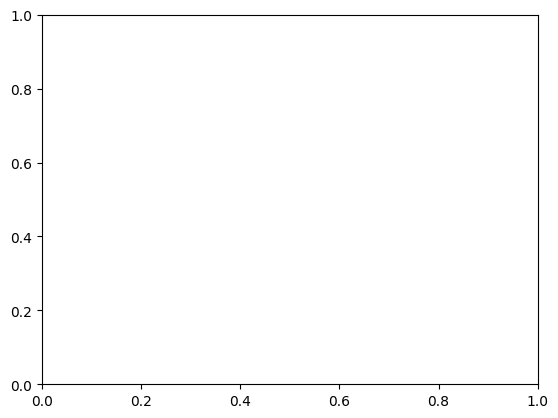

In [89]:
ind = 1960
fig, ax = plt.subplots(1,1)

ax.plot(df.loc[ind]['freq'], df.loc[ind]['phdos'],label="Total")

for i in range(1,len(df.loc[ind].site_phdos)):
    ax.plot(df.loc[ind]['freq'], df.loc[ind].site_phdos[i],'--',label="Site "+str(i+1))

ax.set_ylabel(r"F($\omega$) states/meV/unit_cell")
ax.legend()
#axs[0].set_ylim(0,1)

In [ ]:
df_null = df.loc[df.freq.isnull()]

In [15]:
root

'/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/'

In [24]:
inds = []
for ind in df_null.index:
    d = root+f'{ind}/phonon_2x2x2/'
    if os.path.isfile(d+'CRASH') == False:
        print(d)
        inds.append(ind)
    # else:
        # print(d)
    #     print(os.listdir(d))

/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/58517/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/49588/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/44525/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/46725/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/53432/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/61819/phonon_2x2x2/


In [25]:
root_relaxed = f'/blue/hennig/jasongibson/elemental_sub/materials/{par_el}/mp_relaxed/'
with open(root_relaxed+'list_ele', "w") as file:
    for item in inds:
        # Write each item to the file followed by a newline
        file.write(f"{item}\n")

In [4]:
root = '/blue/hennig/jasongibson/elemental_sub/Be/mp_relaxed/1655'
jobdir = root +'/qe_test/test_2'

filename = jobdir+"/relax.out"
atom_obj = ase.io.read(filename)

In [5]:
Ph_2x2x2_interpolated_Freq_meV = []
Ph_2x2x2_interpolated_Tot_DOS = []
Ph_2x2x2_interpolated_Site_Proj_DOS = []


freq, phdos, site_proj_phdos = get_freq_phonon_2x2x2_interpolated_DOS(jobdir +"/phonon_2x2x2/"+".dos", atom_obj.get_global_number_of_atoms())
Ph_2x2x2_interpolated_Freq_meV.append(freq)
Ph_2x2x2_interpolated_Tot_DOS.append(phdos)
Ph_2x2x2_interpolated_Site_Proj_DOS.append(site_proj_phdos)


<Figure size 640x480 with 0 Axes>

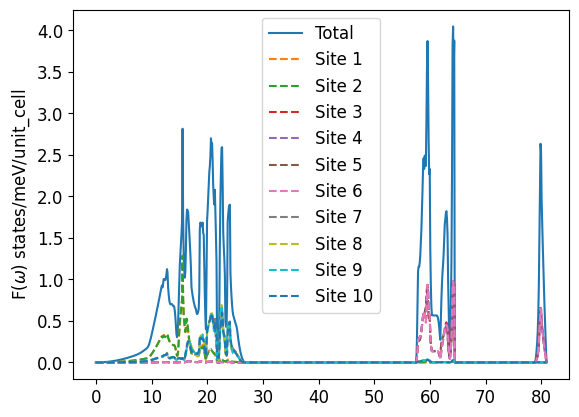

In [7]:
plt.clf()
plt.rcParams.update({'font.size': 12})
# plt.rcParams["font.family"] = "Times New Roman"

plt.subplots_adjust(left=0.15,bottom=0.07,right=0.99,top=0.99,hspace=0.05)
fig, ax = plt.subplots(1,1)

# mat_data = data3.iloc[2]#data.iloc[data[data["comp_name"]=="Mg1B2_JVASP_19821"].index[0]]

ax.plot(freq, phdos,label="Total")

for i in range(0,atom_obj.get_global_number_of_atoms()):
    ax.plot(freq, site_proj_phdos[i],'--',label="Site "+str(i+1))

ax.set_ylabel(r"F($\omega$) states/meV/unit_cell")
ax.legend()
#axs[0].set_ylim(0,1)

# axs[1].plot(mat_data["a2F_Freq_meV_sigma_2"],mat_data["a2F_sigma_2"])



# axs[1].set_ylabel(r"$\alpha^2$F($\omega$)")

# axs[2].plot(mat_data["Ph_2x2x2_interpolated_Freq_meV"],
#             mat_data["Ph_2x2x2_interpolated_Tot_DOS"],label="Total")

# for i in range(0,mat_data["ase_atom_obj"].get_global_number_of_atoms()):
#     axs[2].plot(mat_data["Ph_2x2x2_interpolated_Freq_meV"],
#                 mat_data["Ph_2x2x2_interpolated_Site_Proj_DOS"][i],
#                 '--',label="Site "+str(i+1))

In [17]:
def cal_lambda(freq_w,alpha_F):
    lambdaF = 0
    for i in range(1,len(freq_w)):
        dw = freq_w[i] - freq_w[i-1]
        if freq_w[i] >0:
            w = freq_w[i]
            alpha_F_w = alpha_F[i]
            lambdaF = lambdaF + ((alpha_F_w/w)*dw)
        
    return 2*lambdaF

def cal_w_log(freq_w,alpha_F,lamb):
    w_logF = 0
    for i in range(1,len(freq_w)):
        dw = freq_w[i] - freq_w[i-1]
        if freq_w[i] >0:
            w_logF = w_logF + (alpha_F[i]*np.log(freq_w[i])*dw/freq_w[i])
    
    return np.exp(2*w_logF/lamb)

def cal_w_sq(freq_w,alpha_F,lamb):
    w_sqF = 0
    for i in range(1,len(freq_w)):
        if freq_w[i] >0:
            dw = freq_w[i] - freq_w[i-1]
            w_sqF = w_sqF + (alpha_F[i]*freq_w[i]*dw)
        
    return 2*w_sqF/lamb

In [18]:
unitcell_vol = []
aw_list = []

phlam = []
phwlog = []
phw2 = []


for i in data3.iloc:
    aw = []
    for j in i["ase_atom_obj"]:
        aw.append(j.mass)
    aw_list.append(aw)
    unitcell_vol.append(i["ase_atom_obj"].get_volume())
            

    if (type(i["Ph_2x2x2_interpolated_Freq_meV"]) == list):
        phlam.append(cal_lambda(freq_w=i["Ph_2x2x2_interpolated_Freq_meV"],
                                    alpha_F=i["Ph_2x2x2_interpolated_Tot_DOS"]))
            
        phwlog.append(cal_w_log(freq_w=i["Ph_2x2x2_interpolated_Freq_meV"],
                                    alpha_F=i["Ph_2x2x2_interpolated_Tot_DOS"],
                                    lamb=phlam[-1]))
            
        phw2.append(np.sqrt(cal_w_sq(freq_w=i["Ph_2x2x2_interpolated_Freq_meV"],
                                         alpha_F=i["Ph_2x2x2_interpolated_Tot_DOS"],
                                         lamb=phlam[-1])))

    else:
        phlam.append(np.nan)
        phwlog.append(np.nan)
        phw2.append(np.nan)

In [19]:
data3["AW"] = aw_list
data3["unitcell_vol"] = unitcell_vol

data3["phlam"] = phlam
data3["phwlog"] = phwlog
data3["phw2"] = phw2

In [20]:
len(data3)

5260

In [21]:
data3.dropna(inplace=True)
data3.reset_index(inplace=True,drop=True)

In [22]:
len(data3)

5242

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import r_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

<Figure size 640x480 with 0 Axes>

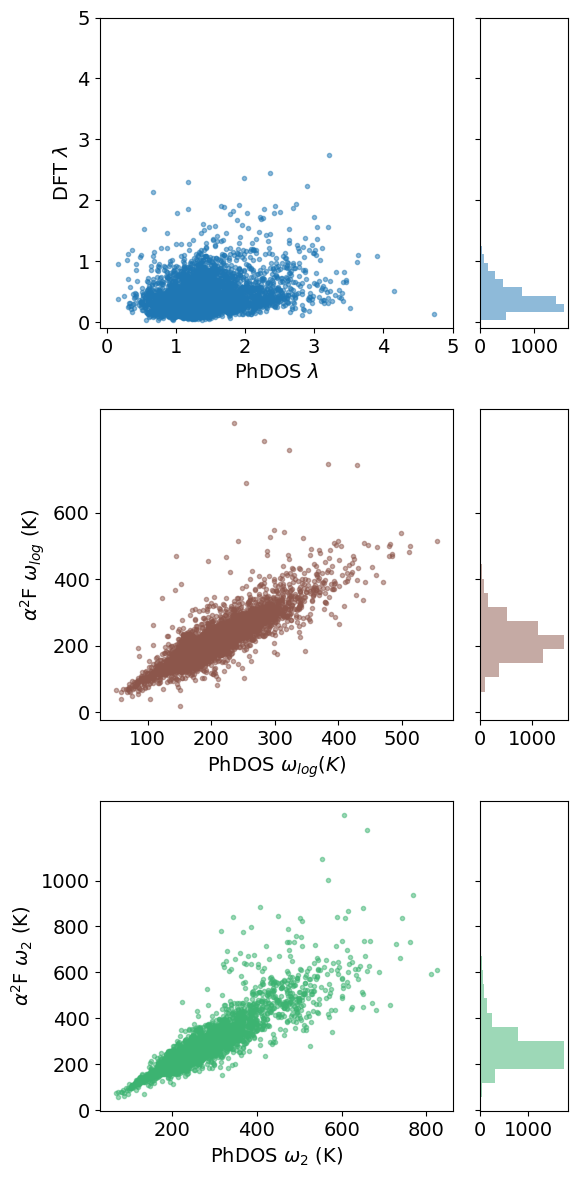

In [26]:
lreg = LinearRegression(fit_intercept=True,copy_X=True)

plt.clf()
plt.rcParams.update({'font.size': 14})
plt.rcParams["font.family"] = "sans-serif"

plt.subplots_adjust(left=0.05,bottom=0.07,right=0.99,top=0.99)
fig, axs = plt.subplots(3,2,figsize=(6,12),width_ratios=(4,1),sharey='row')

# #X_train, Y_train = np.array([training_data["dos_at_ef"]]), training_data["lambda"]
# X_train, Y_train = np.array(training_data["phlam"]), np.array(training_data["lambda"])
# mask = ~np.isnan(X_train) & ~np.isnan(Y_train)
# X_train = np.array([X_train[mask]])
# Y_train = Y_train[mask]

# #X_test, Y_test = np.array([testing_data["dos_at_ef"]]), testing_data["lambda"]
# X_test, Y_test = np.array(testing_data["phlam"]), np.array(testing_data["lambda"])
# mask = ~np.isnan(X_test) & ~np.isnan(Y_test)
# X_test = np.array([X_test[mask]])
# Y_test = np.array(Y_test[mask])


# reg = lreg.fit(X_train.transpose(),Y_train)

axs[0][0].scatter(data3['phlam'],data3['ACH_lambda_sigma_2'],marker='.',alpha=0.5,color='C0')
axs[0][1].hist(data3['ACH_lambda_sigma_2'],alpha=0.5,color='C0',orientation='horizontal',bins=20)

axs[0][0].set_xlabel(r"PhDOS $\lambda$")
axs[0][0].set_ylabel(r"DFT $\lambda$")

# X_data, Y_data = np.array(data3["phlam"]), np.array(data3["ACH_lambda_sigma_2"])
# mask = ~np.isnan(X_data) & ~np.isnan(Y_data)
# X_data = np.array([X_data[mask]])
# Y_data = Y_data[mask]
# data_pear_r = r_regression(X_data.transpose(),Y_data)

# print("Lambda:\n"+
#       r"Data Pearson r ="+str(round(data_pear_r[0],2)))# + "\n" +
#       r"Training $R^2$ ="+str(round(reg.score(X_train.transpose(),Y_train),2)) + "\n" + 
#       r"Training MAE ="+str(round(mean_absolute_error(Y_train, reg.predict(X_train.transpose())),2)) + "\n" +
#       r"Training RMSE ="+str(round(mean_squared_error(Y_train, reg.predict(X_train.transpose()), squared=False),2)) + "\n" +
#       "\n" +
#       r"Testing $R^2$ ="+str(round(reg.score(X_test.transpose(),Y_test),2)) + "\n"
#       r"Testing MAE ="+str(round(mean_absolute_error(Y_test, reg.predict(X_test.transpose())),2)) + "\n" +
#       r"Testing RMSE ="+str(round(mean_squared_error(Y_test, reg.predict(X_test.transpose()), squared=False),2)) + "\n" )

axs[0][0].set_xlim(-0.1,5)
axs[0][0].set_ylim(-0.1,5)
# axs[0].set_aspect('equal')

# X_train, Y_train = np.array(training_data["phwlog"])/0.08617, np.array(training_data["w_log"])/0.08617
# mask = ~np.isnan(X_train) & ~np.isnan(Y_train)
# X_train = np.array([X_train[mask]])
# Y_train = Y_train[mask]

# X_test, Y_test = np.array(testing_data["phwlog"])/0.08617, np.array(testing_data["w_log"])/0.08617
# mask = ~np.isnan(X_test) & ~np.isnan(Y_test)
# X_test = np.array([X_test[mask]])
# Y_test = np.array(Y_test[mask])

# training_pear_r = r_regression(X_train.transpose(),Y_train)
# reg = lreg.fit(X_train.transpose(),Y_train)

axs[1][0].scatter(data3['phwlog']/0.08617,data3['ACH_w_log_sigma_2']/0.08617,marker='.',alpha=0.5,color='C5')
axs[1][1].hist(data3['ACH_w_log_sigma_2']/0.08617,alpha=0.5,color='C5',orientation='horizontal',bins=20)
#axs[1].plot(X_train.transpose(),reg.predict(X_train.transpose()),"k--")

axs[1][0].set_xlabel(r"PhDOS $\omega_{log} (K)$")
axs[1][0].set_ylabel(r"$\alpha^2$F $\omega_{log}$ (K)")

#axs[1][0].set_title(r"Pearson r ="+str(round(training_pear_r[0],2)))

# X_data, Y_data = np.array(data3["phwlog"])/0.08617, np.array(data3["ACH_w_log_sigma_2"])/0.08617
# mask = ~np.isnan(X_data) & ~np.isnan(Y_data)
# X_data = np.array([X_data[mask]])
# Y_data = Y_data[mask]
# data_pear_r = r_regression(X_data.transpose(),Y_data)


# print("omega_log:\n"+
#       r"Data Pearson r ="+str(round(data_pear_r[0],2)))# + "\n" +
#       r"Training $R^2$ ="+str(round(reg.score(X_train.transpose(),Y_train),2)) + "\n" +
#       r"Training MAE ="+str(round(mean_absolute_error(Y_train, reg.predict(X_train.transpose())),2)) + "K \n" +
#       r"Training RMSE ="+str(round(mean_squared_error(Y_train, reg.predict(X_train.transpose()), squared=False),2)) + "K \n" +
#       "\n" +
#       r"Testing $R^2$ ="+str(round(reg.score(X_test.transpose(),Y_test),2)) + "\n"
#       r"Testing MAE ="+str(round(mean_absolute_error(Y_test, reg.predict(X_test.transpose())),2)) + "K \n" +
#       r"Testing RMSE ="+str(round(mean_squared_error(Y_test, reg.predict(X_test.transpose()), squared=False),2)) + "K \n" )

xticks = axs[1][0].get_xticks()
axs[1][0].set_yticks(xticks)
#axs[1][0].set_xlim(-0.3,810)
#axs[1][0].set_ylim(-0.3,810)
# axs[1].set_aspect('equal')

# X_train, Y_train = np.array(training_data["phw2"])/0.08617, np.sqrt(training_data["w_sq"])/0.08617
# mask = ~np.isnan(X_train) & ~np.isnan(Y_train)
# X_train = np.array([X_train[mask]])
# Y_train = Y_train[mask]

# X_test, Y_test = np.array(testing_data["phw2"])/0.08617, np.sqrt(testing_data["w_sq"])/0.08617
# mask = ~np.isnan(X_test) & ~np.isnan(Y_test)
# X_test = np.array([X_test[mask]])
# Y_test = np.array(Y_test[mask])

# training_pear_r = r_regression(X_train.transpose(),Y_train)
# reg = lreg.fit(X_train.transpose(),Y_train)

axs[2][0].scatter(data3['phw2']/0.08617,np.sqrt(list(data3['ACH_w_sq_sigma_2']))/0.08617,
                  marker='.',alpha=0.5,
                  color='mediumseagreen')
axs[2][1].hist(np.sqrt(list(data3['ACH_w_sq_sigma_2']))/0.08617,
               alpha=0.5,color='mediumseagreen',orientation='horizontal',bins=20)

# axs[2][0].set_xlabel(r"PhDOS $\sqrt{\omega^2}$ (K)")
# axs[2][0].set_ylabel(r"$\alpha^2$F $\sqrt{\omega^2}$ (K)")

axs[2][0].set_xlabel(r"PhDOS $\omega_2$ (K)")
axs[2][0].set_ylabel(r"$\alpha^2$F $\omega_2$ (K)")

#axs[2][0].set_title(r"Pearson r ="+str(round(training_pear_r[0],2)))

# X_data, Y_data = np.array(data3["phw2"])/0.08617, np.sqrt(data3["ACH_w_sq_sigma_2"])/0.08617
# mask = ~np.isnan(X_data) & ~np.isnan(Y_data)
# X_data = np.array([X_data[mask]])
# Y_data = Y_data[mask]
# data_pear_r = r_regression(X_data.transpose(),Y_data)

# print("omega^2\n"+
#       r"Data Pearson r ="+str(round(data_pear_r[0],2)))# + "\n" +
      # r"Training $R^2$ ="+str(round(reg.score(X_train.transpose(),Y_train),2)) + "\n" +
      # r"Training MAE ="+str(round(mean_absolute_error(Y_train, reg.predict(X_train.transpose())),2)) + "K \n" +
      # r"Training RMSE ="+str(round(mean_squared_error(Y_train, reg.predict(X_train.transpose()), squared=False),2)) + "K \n" +
      # "\n" +
      # r"Testing $R^2$ ="+str(round(reg.score(X_test.transpose(),Y_test),2)) + "\n"
      # r"Testing MAE ="+str(round(mean_absolute_error(Y_test, reg.predict(X_test.transpose())),2)) + "K \n" +
      # r"Testing RMSE ="+str(round(mean_squared_error(Y_test, reg.predict(X_test.transpose()), squared=False),2)) + "K \n" )


xticks = axs[2][0].get_xticks()
axs[2][0].set_yticks(xticks)
#axs[2][0].set_xlim(-0.3,1000)
#axs[2][0].set_ylim(-0.3,1000)
# axs[2][0].set_aspect('equal')

plt.tight_layout()

In [29]:
data3

,comp,ID,dir_name,ase_atom_obj,a2F_Freq_meV_sigma_5,a2F_sigma_5,a2F_Freq_meV_sigma_2,a2F_sigma_2,PhFreq_meV,Tot_PhDOS,...,ACH_w_sq_sigma_2,ACH_w_sq_sigma_5,Ph_2x2x2_interpolated_Freq_meV,Ph_2x2x2_interpolated_Tot_DOS,Ph_2x2x2_interpolated_Site_Proj_DOS,AW,unitcell_vol,phlam,phwlog,phw2
0,TiZr2Hf,agm001117008,batch-a/TiZr2Hf_agm001117008,"(Atom('Hf', [1.5545413949488431, 1.55454139494...","[0.3099610662768737, 0.433944404331305, 0.5579...","[3.78827e-06, 1.0395e-05, 2.20932e-05, 9.63046...","[0.3099610662768737, 0.433944404331305, 0.5579...","[3.74098e-06, 1.02653e-05, 2.18174e-05, 0.0001...","[-3.27827707685721e-07, 0.12398392948682858, 0...","[0.0, 2.9633224103364845e-05, 0.00011853293754...",...,144.770021,146.740253,"[-2.8712443137094725e-07, 0.1000005794401343, ...","[0.0, 3.592022115913284e-05, 0.000143681216501...","[[0.0, 1.5672150981763196e-05, 6.2643436902454...","[178.49, 91.224, 91.224, 47.867]",82.790253,2.025927,10.999947,13.204543
1,Ti2Tc,agm001850181,batch-a/Ti2Tc_agm001850181,"(Atom('Ti', [0.0, 0.0, 6.17470978133578], inde...","[0.3099597057064761, 0.433944404331305, 0.5579...","[3.65996e-06, 1.00429e-05, 2.43003e-05, 6.0852...","[0.3099597057064761, 0.433944404331305, 0.5579...","[4.54172e-06, 1.24625e-05, 2.97945e-05, 7.3975...","[-7.408069556149091e-07, 0.12398351650766588, ...","[0.0, 9.28629968461457e-06, 3.714520594501837e...",...,442.509367,440.894069,"[-6.86077933671161e-07, 0.10000018048607079, 0...","[0.0, 1.7984255786101776e-06, 7.19371149923581...","[[0.0, 4.442499490893504e-07, 1.77578996534136...","[47.867, 47.867, 97.90721]",45.683695,0.847788,19.976235,22.268911
2,TiNb2Mo,agm002322068,batch-a/TiNb2Mo_agm002322068,"(Atom('Ti', [0.0, 0.0, 0.0], index=0), Atom('N...","[0.3099597057064761, 0.433944404331305, 0.5579...","[1.0947e-05, 3.00387e-05, 6.38432e-05, 0.00027...","[0.3099597057064761, 0.433944404331305, 0.5579...","[1.24171e-05, 3.40725e-05, 7.24166e-05, 0.0002...","[-6.26661135782e-07, 0.12398363065377238, 0.24...","[0.0, 3.374342803196467e-05, 0.000134973774666...",...,352.305877,348.385639,"[-3.8213266591462075e-07, 0.1000004844309979, ...","[0.0, 1.720332688031231e-05, 6.8813314894766e-...","[[0.0, 2.5053180680126003e-06, 1.0049662973226...","[47.867, 92.90637, 92.90637, 95.95]",66.085084,1.394697,15.328235,18.122709
3,Cr4TaW,agm003199689,batch-a/Cr4TaW_agm003199689,"(Atom('Ta', [5.09579831601969, 5.0957983160196...","[0.3099597057064761, 0.433944404331305, 0.5579...","[5.095e-07, 1.39807e-06, 2.97141e-06, 5.42516e...","[0.3099597057064761, 0.433944404331305, 0.5579...","[6.89006e-07, 1.89063e-06, 4.01829e-06, 7.3365...","[-1.1285933676141665e-06, 0.12398312872086444,...","[0.0, 1.188429008013745e-05, 4.753726013483484...",...,462.433832,484.472165,"[-1.170317608711315e-06, 0.0999996962469562, 0...","[0.0, 1.2351614770826739e-05, 4.94067870305873...","[[0.0, 3.904205344157425e-06, 1.56253708491430...","[180.94788, 51.9961, 51.9961, 51.9961, 51.9961...",78.413874,1.789248,17.902765,22.689554
4,ScZr2Hf,agm001224362,batch-a/ScZr2Hf_agm001224362,"(Atom('Hf', [2.231190766080766, 2.231190766080...","[0.3099597057064761, 0.433944404331305, 0.5579...","[1.98777e-06, 5.45444e-06, 1.15927e-05, 2.8097...","[0.3099597057064761, 0.433944404331305, 0.5579...","[2.71001e-06, 7.43627e-06, 1.58048e-05, 3.8586...","[-4.7407814988331473e-07, 0.12398378323623849,...","[0.0, 2.5589694772645687e-05, 0.00010235881498...",...,191.259416,193.25882,"[-4.422155281254245e-07, 0.10000042434822681, ...","[0.0, 1.7738153301311985e-05, 7.09527339213801...","[[0.0, 7.842608578368205e-06, 3.15402945881246...","[178.49, 91.224, 91.224, 44.955908]",88.499474,1.700905,12.417268,14.220628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5237,Al2ZnMo,agm003186213,batch-q/Al2ZnMo_agm003186213,"(Atom('Al', [0.0, 0.0, 4.243290309763619], ind...","[0.3099610662768737, 0.433944404331305, 0.5579...","[4.70358e-08, 1.29066e-07, 2.74313e-07, 5.0083...","[0.3099610662768737, 0.433944404331305, 0.5

In [28]:
data3.to_pickle("qe_data_imaginary_removed_w_Ph_2x2x2_interpolated_DOS.pkl")

In [114]:
data3[data3['phwlog']/0.08617 <= 50][["dir_name","phwlog","ACH_w_log_sigma_2"]]

,dir_name,phwlog,ACH_w_log_sigma_2
41,batch-a/N4ScHf3_agm003557883,0.858381,21.477578
63,batch-a/ZrNbTa_agm001839730,3.725712,13.549953
71,batch-a/Cr4NbW_agm001173535,0.250333,17.741171
112,batch-a/ZrHf_agm004451102,1.448806,11.274664
129,batch-a/P4Zr3Hf_agm003562840,1.982179,9.332285
...,...,...,...
4583,batch-n/AlCu2Zn_agm002134662,2.986728,16.951052
4883,batch-o/Al2Ni3Cu_agm003437123,0.270270,19.102504
5122,batch-p/As2ZrHf_agm005120946,0.402166,16.795058
5202,batch-p/Cu2ZnGa_agm002146024,2.942377,15.895116


In [109]:
temp[["phwlog","ACH_w_log_sigma_2"]]

,phwlog,ACH_w_log_sigma_2
41,0.858381,21.477578
63,3.725712,13.549953
71,0.250333,17.741171
112,1.448806,11.274664
129,1.982179,9.332285
...,...,...
4583,2.986728,16.951052
4883,0.270270,19.102504
5122,0.402166,16.795058
5202,2.942377,15.895116


In [7]:
import ase.io

In [10]:
ase_atom = ase.io.read("batch-b/B2Mg_agm002077195/scf_coarse.in")

In [12]:
import subprocess

In [38]:
proc = subprocess.Popen(["grep -A 1 'K_POINTS' batch-b/B2Mg_agm002077195/scf_coarse.in"],
                        stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT,shell=True)

output, error = proc.communicate()
output = output.decode("utf-8")
output = output.split()
k_grid = [int(output[2]), int(output[3]), int(output[4])] 

In [39]:
k_grid

[8, 8, 8]

In [33]:
output

b'K_POINTS automatic\n  8 8 8 0 0 0\n'

['K_POINTS', 'automatic', '8', '8', '8', '0', '0', '0']